In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.evaluation as ev
import nibabel as nb
import PcmPy as pcm

In [2]:
# load X
traindata = gl.traindata_string()
X = nb.load(gl.conn_dir + f'/maps/{traindata}_data_cortex.pscalar.nii').get_fdata().squeeze()
Q = X.shape[1]

# load yeo
yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_Icosahedron1002.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
label_dict = yeo_img.header.get_axis(0).label[0]
names = [label_dict[i+1][0] for i in range(17)]
colors = [label_dict[i+1][1] for i in range(17)]
labels_int = yeo_data.astype(int)
label_to_name = {i+1: names[i] for i in range(len(names))}

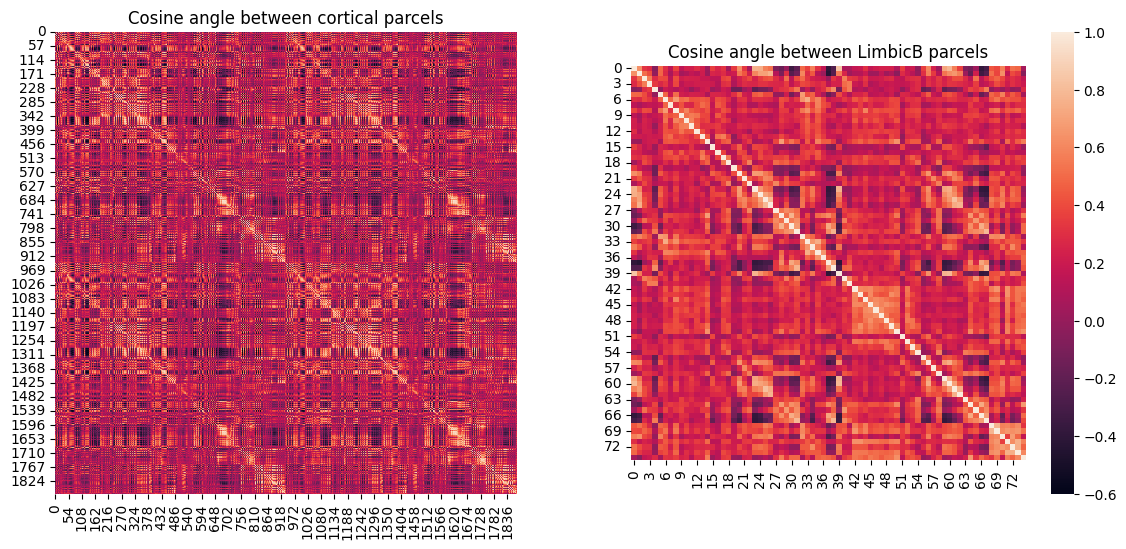

In [35]:
# normalized X
X = rm.std_data(X, mode='parcel')
# since length of X parcels are 1, cosine angle is the inner product:
cos_angle = X.T @ X

plt.subplots(1,2,figsize=(14,6))
plt.subplot(1,2,1)
sns.heatmap(cos_angle, square=True, vmin=-0.6, vmax=1, cbar=False);
plt.title('Cosine angle between cortical parcels');

C_OF = cos_angle[np.ix_(yeo_data==10, yeo_data==10)]
plt.subplot(1,2,2)
sns.heatmap(C_OF, square=True, vmin=-0.6, vmax=1);
plt.title('Cosine angle between LimbicB parcels');

The functional similarity between right hemisphere and left hemisphere is clearly observed.

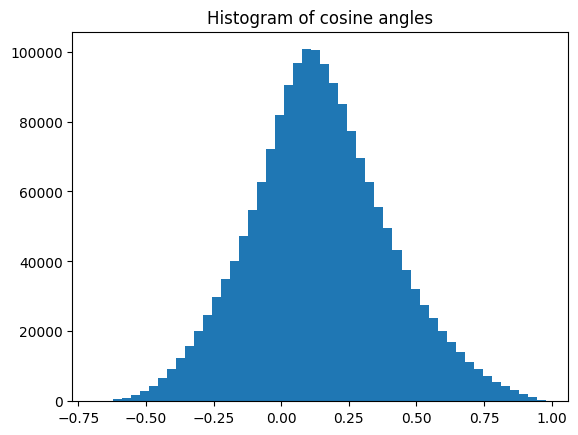

In [4]:
C = cos_angle[np.triu_indices_from(cos_angle, k=1)]
plt.hist(C, bins=50)
plt.title('Histogram of cosine angles');

In [5]:
thresholds = np.percentile(C, [96, 99, 99.5, 99.9])
print("Adaptive thresholds:", thresholds)

Adaptive thresholds: [0.62157147 0.7734538  0.82792021 0.9064418 ]


In [ ]:
counts = np.zeros((Q, len(thresholds)), dtype=np.int32)

for j, t in enumerate(thresholds):
    counts[:, j] = (cos_angle >= t).sum(axis=1) - 1  # remove self

# neighbor score
counts_norm = counts / Q * 100

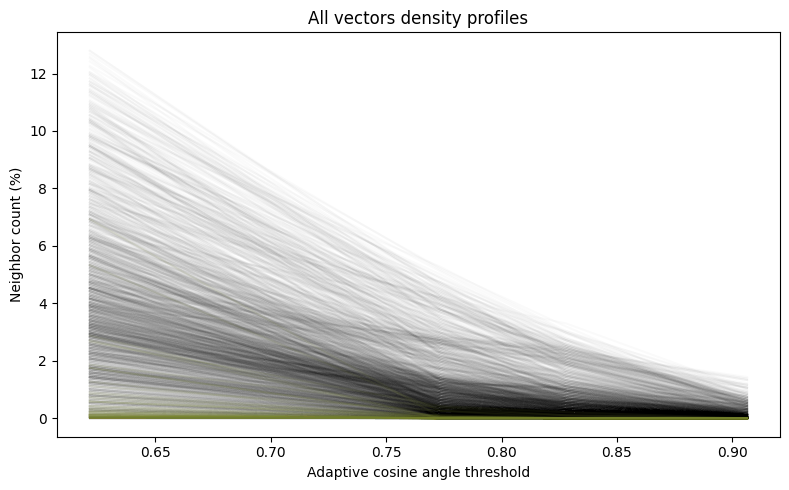

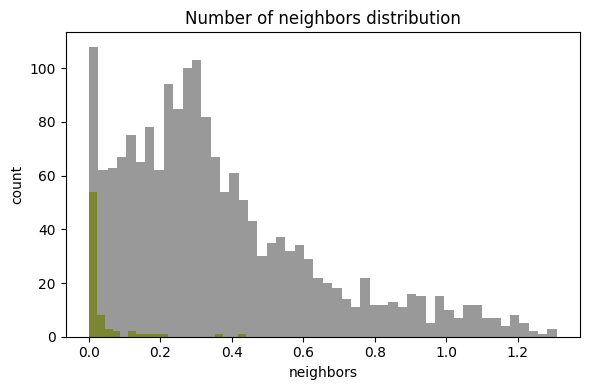

In [ ]:
# full cloud visualization
plt.figure(figsize=(8, 5))
of_ind = yeo_data == 10
for i in range(Q):
    if ~of_ind[i]:
        plt.plot(thresholds, counts_norm[i], color='black', alpha=0.02)
for i in range(Q):
    if of_ind[i]:
        plt.plot(thresholds, counts_norm[i], color=colors[9], alpha=0.1)
    

plt.xlabel("Adaptive cosine angle threshold")
plt.ylabel("Neighbor count (%)")
plt.title("All vectors density profiles")
plt.tight_layout()
plt.show()

# plot neighbor distribution
plt.figure(figsize=(6, 4))
plt.hist(np.mean(counts_norm[~of_ind], axis=1)/len(thresholds), bins=50, color='black', alpha=0.4)
plt.hist(np.mean(counts_norm[of_ind], axis=1)/len(thresholds), bins=20, color=colors[9])
plt.title("Number of neighbors distribution")
plt.xlabel("neighbors")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [26]:
# rank networks by loneliness
df = pd.DataFrame({
    "label": labels_int,
    "num_neighbors": np.mean(counts_norm, axis=1)/len(thresholds),
})
df["name"] = df["label"].map(label_to_name)

group_stats = df.groupby(["name"])["num_neighbors"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
    max="max"
)

ranked = group_stats.sort_values("mean", ascending=False)
print(ranked)

                          mean    median       std  count       max
name                                                               
05.DorsalAttentionA   0.748100  0.772921  0.323797    111  1.252665
01.VisualA            0.675160  0.689632  0.248677    125  1.082756
06.DorsalAttentionB   0.613251  0.593017  0.234775    109  1.242671
12.ControlA           0.579293  0.553038  0.396150    109  1.309302
08.VentralAttentionB  0.370730  0.333156  0.247360     97  0.906183
04.SomatomotorB       0.366996  0.316498  0.187889    146  0.699627
11.ControlC           0.327422  0.193230  0.295847     43  1.122735
14.TemporalParietal   0.324726  0.301506  0.121160     66  0.686301
07.VentralAttentionA  0.305665  0.293177  0.142441    151  0.772921
02.VisualB            0.296476  0.304837  0.103321    102  0.546375
13.ControlB           0.283216  0.213220  0.227367    100  0.896189
03.SomatomotorA       0.242014  0.226546  0.107441    182  0.539712
17.DefaultB           0.231678  0.216551  0.1525

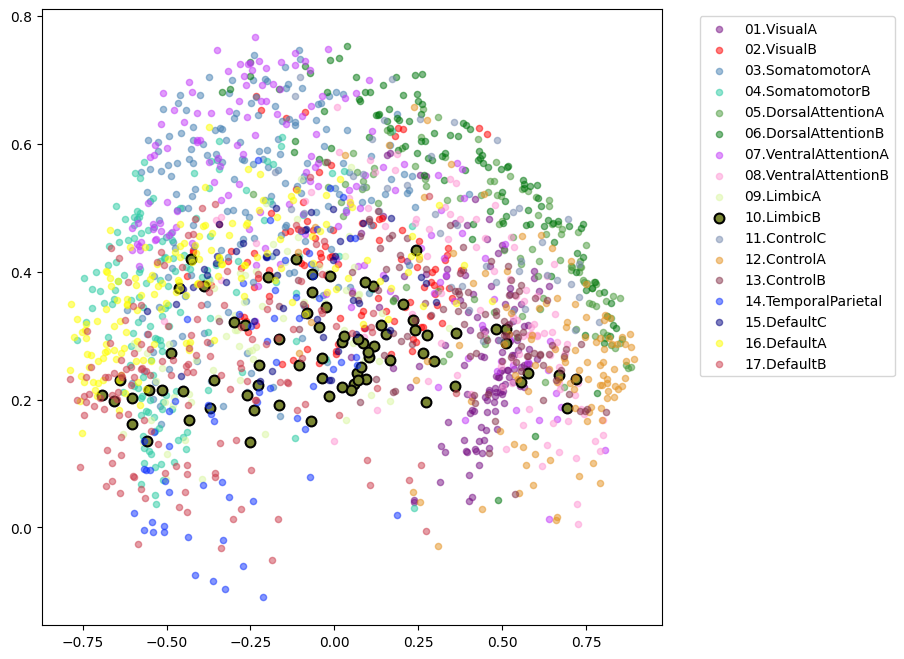

In [27]:
dim = "2D" # "2D" or "3D"
W, _ = pcm.util.classical_mds(cos_angle)

if dim == "2D":
    fig, ax = plt.subplots(figsize=(8,8))
    for i, (name, color) in enumerate(zip(names, colors)):
        ind = yeo_data == i+1
        if i+1 == 10:
            ax.scatter(W[ind, 0], W[ind, 1], color=color, s=50, alpha=1, edgecolors='k', linewidths=1.5)
        else:
            ax.scatter(W[ind, 0], W[ind, 1], color=color, s=20, alpha=0.5)
    ax.legend(labels=names, loc='upper left', bbox_to_anchor=(1.05, 1))
elif dim == "3D":
    ax = plt.figure(figsize=(8,8)).add_subplot(111, projection='3d')
    for i, (name, color) in enumerate(zip(names, colors)):
        ind = yeo_data == i+1
        if i+1 == 10:
            ax.scatter(W[ind, 0], W[ind, 1], W[ind,2], color=color, s=50, alpha=1, edgecolors='k', linewidths=1.5)
        else:
            ax.scatter(W[ind, 0], W[ind, 1], W[ind,2], color=color, s=20, alpha=0.5)
    ax.legend(labels=names, loc='upper left', bbox_to_anchor=(1.05, 1))

In [28]:
def class_density(cos_angle, label, names):
    scores = {}

    for n, name in enumerate(names):
        Cc = cos_angle[np.ix_(label == n+1, label == n+1)]
        scores[name] = np.mean(Cc[np.triu_indices_from(Cc, k=1)])

    return scores

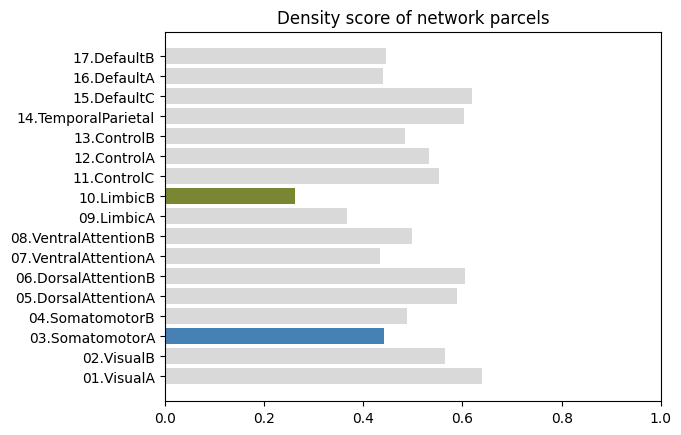

In [29]:
scores = class_density(cos_angle, yeo_data, names)
emph_ind = [2, 9]
emph_colors = [color if i in emph_ind else (0.85, 0.85, 0.85, 1.0) for i, color in enumerate(colors)]
plt.barh(list(scores.keys()), list(scores.values()), color=emph_colors)
plt.xlim((0, 1))
plt.title('Density score of network parcels');